# TODO
* [DONE] Fixa en alternativ version av varje LLM så att istället för att bara prompta om att svara på frågan ska den nu prompta för att
  göra en tidigare text bättre. För varje generation efter den första ska den ta system prompt, bästa draften (som den tidigare genererat), delta feedback som beskriver vad som ändrats sista rundan,nya problem, färdiga problem och kvarvarande problem, och sista är user prompt.

* [DONE] Bygg upp en improvement-loop och testa så att det blir bättre
* [DONE] I körloopen så bygg upp så allting läggs i en JSON fil, varje sample etc. för att om det skulle krasha så slipper man köra om
* [DONE] Lägg till engelska
* [DONE] Strukturera om och bygg loopen under kapitlet för loop, och kör lite på vanilla och testa nästa steg med.
* Gör KL/JS-Divergence. Men istället för att försöka hitta en bok som beskriver och jämföra, så generera svaret utan några begränsningar alls och jämför distribution med den, vilket gör att man kan läsa av stylistiska skillnader mellan en vanlig välfungerande generation och vad som skiljer sig i denna. (https://chatgpt.com/share/69ed127d-e0d4-832d-8baf-36bd3278298c)
* Bygg upp Lexical constraints graf. Gör så att x axeln är varje improvement loop, y axeln är hur mycket error från target 90% och averagea och sen kör standard deviation. Sen gör också en procent som visar hur många samples som successfully nådde sig inom gränsen.
* Bygg en convergence här så om alla measurements har stabiliserat, sluta i förväg.
* Kör varje modell för:
  - 20/50/100 i sample size *
  - 3-10 i improvement loop *
  - 3-10 st olika batch sizes (100, 500, 2000 kanske?) *
  - För alla 3 språk *
* Presentera resultat över 100 samples (alt. 50 om för dyrt).
* Skriv rapporten

# NILAS (Nuimio Intelligent Language Assistant System)

NILAS (Nuimio Intelligence Language Agent System) is a subsystem developed for the award-winning language platform [Nuimio](https://nuimio.com). The project aims to enable seamless integration of AI & Machine Learning into the current algorithmic nature of Nuimio. It uses a flexible architecture built on iterative improvements using a varied set of closed-source models for increased performance.

This is the main file for Dennis Mitzeus' bachelor thesis project for the program Applied Artificial Intelligence 2026 at Halmstad University. The project includes data preprocessing, project structuring, technical implementation, and evaluation.

The current Architecture looks like this:

<img width="400px" src="./figures/artifact_flowchart_new.png"></img>

## Structure

This project will go through

1. Data Preprocessing
2. API setup
3. Technical Setup
4. Improvement Loop
5. Evaluation

## Project

In [1]:
# Setting up warning and logging filters, and mutliprocessing before anything else.
import os
import warnings
os.environ["VLLM_LOGGING_LEVEL"] = "ERROR"  # only show actual errors
os.environ["PYTHONWARNINGS"] = "ignore"
warnings.filterwarnings("ignore")

import logging
logging.getLogger("vllm").setLevel(logging.ERROR)
logging.getLogger("vllm.engine").setLevel(logging.ERROR)

import torch.multiprocessing as mp
from vllm import LLM, SamplingParams

mp.set_start_method("spawn", force=True)

In [2]:
# Fixes need to restart kernel everytime I update components in separate files
%load_ext autoreload
%autoreload 2

%matplotlib inline

# Import Declarations
from IPython.display import Markdown, display
from wordfreq import top_n_list, word_frequency
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
import seaborn as sns
import re
import contractions
from typing import Literal, Optional, get_args, Union
import requests
import tarfile
import shutil
import csv
from dotenv import load_dotenv, dotenv_values
import os
import json
import spacy
import sqlite3
import time

In [3]:
TOTAL_SIZE = 2000 # Total size of each flashcard set
BATCH_SIZE = [100, 500, 2000] # How many words get introduced at a time eg. 20: ask LLM with 20 flashcards, then again with 40, then 60,..., until total size reached
MODEL_SAMPLE_SIZE = 100 # How many times to ask the same question (to get a distribution of probabilistic results)
LANGUAGES = Literal["english", "swedish", "spanish", "korean"]

### Data Preprocessing

#### Status for language Datasets Found:
* ✅ English: wordfreq (https://github.com/rspeer/wordfreq)
* ✅ Swedish: Kelly (https://spraakbanken.gu.se/resurser/kelly)
* ✅ Spanish: ChatSubs (https://linkinghub.elsevier.com/retrieve/pii/S2352340923006650) (Data link: https://github.com/conversa-ai/ChatSubs)
* ✅ Korean: 한국어 학습용 어휘 목록(엑셀 파일) (TOPIK, from National Institute of Korean Language) (https://korean.go.kr/front/etcData/etcDataView.do?etc_seq=71)

#### Dataset explanations

##### English

The English dataset is extracted from the english word frequency list from "wordfreq" and is directly converted to lemmas using spacy.

##### Swedish

The Swedish dataset "Kelly" is used for Swedish. Swedish dataset contains 9 columns: "ID", "Raw freq", "WPM" "CEFR levels", "Source", "Grammar", "Swedish items for translation", "Word classes", and "Examples". 

Raw freq corresponds to the total frequency over the whole extracted corpus, WPM corresponds to a ratio of how many words per 1 000 000 words is this word, CEFR levels correspond to how advanced a word is following the Common European Framework of Reference for Languages, Source is from which corpus the word comes from, Grammar corresponds to certain prefixes or suffixes some word classes inherit (for example "att" before all root verbs), Swedish items for translation is the word itself, word classes correspond to which grammatical type a word is (more details under "Lookup" workspace in file datasets/1-raw/swedish.xls), lastly, examples provide example sentences of use for some words.

##### Spanish

The Spanish dataset "ChatSubs" is a collection of almost 20 000 000 dialogue subtitles from various kinds of movies and series. As this is not a preprocessed list of the most common words, it needs preprocessing.

By structuring all dialogues to be inputted directly into an NLP preprocessing library such as spaCy, a full database of lemmas, their PoS (grammar type) and frequency can be constructed. The frequency and PoS can then be used to determine which words in each grammar type qualify for the final flashcard set.

##### Korean

Korean dataset is from the National Korean Language Institute which is a put together list of the most common words in the Korean language for foreign learners practicing for the TOPIK (Test of Proficiency in Korean) test. Korean dataset contains 5 columns: "순위", "단어", "품사", "풀이", and "등급".

순위 corresponds to the frequency ranking based on a 2002 researcher report named "Survey on Modern Korean Usage Frequency", 단어 corresponds to the word itself, 품사 refers to the grammatical type a word is (more details can be found at [the official dataset site](https://korean.go.kr/front/etcData/etcDataView.do?etc_seq=71)),풀이 refers to the Hanja (漢字) versions of some words, and 등급 refers to which TOPIK level a word is in where A means basic B is intermediate and C is advanced level.

### Preprocessing based on some criteria

For our preprocessing we need to fulfill some critera to get a good subset of the datasets viable for testing in the thesis architecture. 

It requires:

1. Vocabulary list of 100 Words per Language
2. A varied set of grammar types (Nouns, Verbs etc.), some weight more than others such as verbs being more important than conjunctions for basic language.
3. The words should be the most common in most cases. This means relative frequency is better than raw frequency.

#### Batches

Batches are subsets of a final dataset for gradual introduction into the thesis architecture system and works similar to smaller independent datasets inside the bigger one, meaning each batch will have similar word type ratios and not purely based on commonality (in case of a vocabulary list of 100 words, most adjectives may be top 60 meaning no adjectives can ever be used until batches after top 60 gets introduced)

This is a visual image of batches: 

<img src="./figures/flashcard_batches.png" width="400px"></img>

### Preprocessing

In [ ]:
from src.preprocessing.language.general import create_sorted_flashcard_set

In [ ]:
# This is the final structure of each preprocessed final list
final_example_df = pd.DataFrame(
 columns=["word", "pos", "frequency"]
)

for i in range(TOTAL_SIZE):
    final_example_df = pd.concat([final_example_df, pd.DataFrame([{"word": "example word", "pos": "verb", "frequency": 1}])], ignore_index=True)

final_example_df

#### English

In [ ]:
import pandas as pd
import spacy
english_top_n = 5000


# Load spaCy model (gives standard POS tags)
nlp = spacy.load("en_core_web_trf")

# --- 1. Get top 5000 spoken-English words ---
words = top_n_list("en", english_top_n)

data = []

# --- 2. Compute frequency + POS ---
for w in words:
    freq = word_frequency(w, "en")  # spoken/web frequency estimate

    doc = nlp(w)
    pos = doc[0].pos_ if len(doc) > 0 else "X"

    data.append((w, pos, freq))

# --- 3. Create DataFrame ---
english_processed = pd.DataFrame(data, columns=["word", "pos", "frequency"])

# --- 4. Sort just in case ---
english_processed = english_processed.sort_values("frequency", ascending=False).reset_index(drop=True)

english_processed.to_csv(f"data/2-extracted/english{english_top_n}.csv", index=True)

In [ ]:
english_final, class_prior_fig, hamilton_fig = create_sorted_flashcard_set(
    data=english_processed,
    data_columns=["word", "pos", "frequency"],
    pos_str="pos",
    frequency_str="frequency",
    rank_by="frequency",
    lang="english",
    target_columns=["word", "pos", "frequency"],
    drop_pos=["PROPN", "NUM", "PUNCT", "X", ],
    limit=TOTAL_SIZE,
)

display(english_final)
display(class_prior_fig[0])
display(hamilton_fig[0])

#### Swedish

In [ ]:
from src.preprocessing.language.swedish import remove_and_merge_pos as swedish_remove_and_merge_pos

In [ ]:
swedish_raw = pd.read_csv("data/2-extracted/swedish.csv", sep=";")  # import
swedish_raw.isnull().sum()

In [ ]:
# changing WPM to numeric
swedish_raw["WPM"] = swedish_raw["WPM"].str.replace(",", ".").astype("Float64")

# drop rows with super high WPM values (outliers)
swedish_raw = swedish_raw[swedish_raw["WPM"] < 1000000]

In [ ]:
swedish_clump_word_classes = {
    "noun": ["noun", "noun-en", "noun-ett", "noun-en/-ett"],
    "verb": ["verb", "aux verb"],
}

swedish_processed = swedish_remove_and_merge_pos(data=swedish_raw, clump_word_classes=swedish_clump_word_classes)

In [ ]:
swedish_final, class_prior_fig, hamilton_fig = create_sorted_flashcard_set(
    data=swedish_processed,
    data_columns=["Swedish items for translation", "Word classes", "WPM"],
    pos_str="pos",
    frequency_str="frequency",
    rank_by="frequency",
    lang="swedish",
    target_columns=["word", "pos", "frequency"],
    drop_pos=["numeral", "proper name", "particip"],
    limit=TOTAL_SIZE,
)

display(swedish_final)
display(class_prior_fig[0])
display(hamilton_fig[0])

#### Spanish

In [ ]:
from src.preprocessing.language.spanish import load_dataset as load_spanish_dataset
from src.preprocessing.language.spanish import (
    extract_data_from_dataset as spanish_extract_data_from_dataset,
)
from src.preprocessing.language.spanish import (
    grammar_preprocessing as spanish_grammar_preprocessing,
)
from src.preprocessing.language.spanish import (
    finalize_dataset as spanish_finalize_dataset,
)
from src.preprocessing.language.spanish import remove_artifact_entries as spanish_remove_artifact_entries

In [ ]:
load_spanish_dataset() # downloads Spanish Dataset (ChatSubs) to /data/1-raw/spanish/

In [ ]:
spanish_extract_data_from_dataset(limit=20000, limit_sampling_seed=42) # extracts all dialogues from all documents into one .csv document
# spanish_extract_data_from_dataset(limit=1) # extracts all dialogues from all documents into one .csv document

In [ ]:
spanish_df = spanish_grammar_preprocessing(
    nlp_size="small",
    cores_to_use=6,
    import_chunk_size=120000,
    processing_chunk_size=4000,
)  # Does preprocessing: tokenization, lemmatization, PoS tagging

print(spanish_df.sort_values(by="frequency", ascending=False).head(10))

In [ ]:
spanish_raw = spanish_finalize_dataset(limit=5000) # writes and gives top N entries
# spanish_raw = spanish_finalize_dataset(limit=TOTAL_SIZE) # writes and gives top N entries



In [53]:
spanish_raw = pd.read_csv("data/2-extracted/spanish5000.csv", encoding="utf-8")

In [54]:
spanish_processed = spanish_remove_artifact_entries(spanish_raw, word_column="lemma")

Removing artifact entries in data with 5000 rows.
Finished with a total of 4521 rows. (479 removed.)


,word,pos,frequency
0,el,DET,64525.291469
1,de,ADP,47098.875489
2,él,PRON,39082.419037
3,ser,AUX,36387.263155
4,a,ADP,32415.153208
...,...,...,...
4795,mantente,ADV,12.233142
4796,generalmente,ADV,12.233142
4885,escuche,ADV,11.913511
4896,estadir,AUX,11.884454


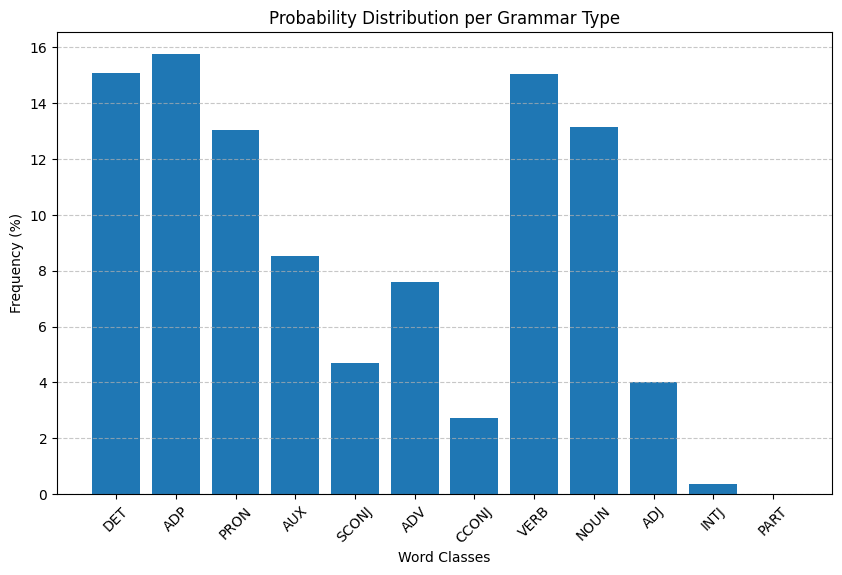

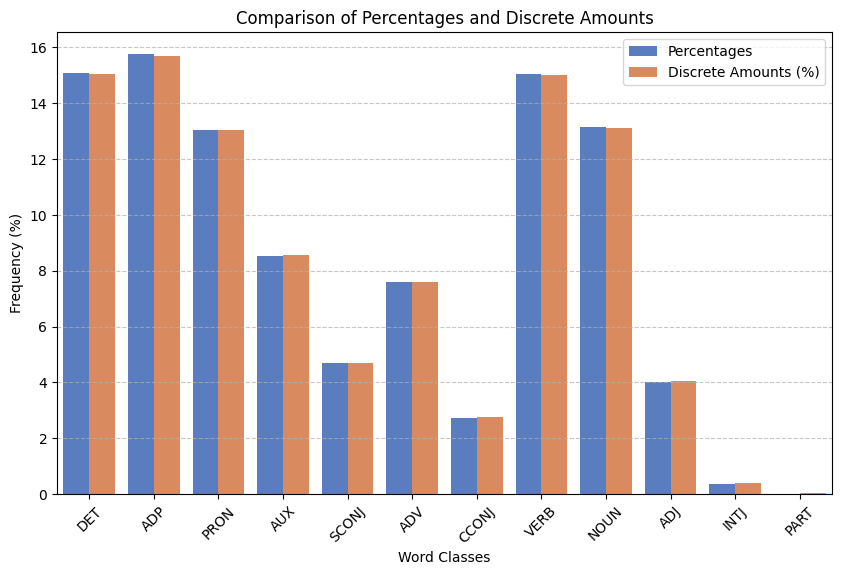

In [55]:
spanish_final, class_prior_fig, hamilton_fig = create_sorted_flashcard_set(
    data=spanish_processed, 
    data_columns=["lemma", "pos", "WPM"], 
    pos_str="pos",
    frequency_str="frequency",
    rank_by="frequency",
    lang="spanish",
    target_columns=["word", "pos", "frequency"], 
    drop_pos=["PROPN", "NUM", "PUNCT"],
    limit=TOTAL_SIZE)

display(spanish_final)
display(class_prior_fig[0])
display(hamilton_fig[0])

#### Korean

In [56]:
korean_raw = pd.read_csv("data/2-extracted/korean.csv", sep=";")  # import
korean_raw.isnull().sum()

순위      68
단어       0
품사       0
풀이    1956
등급       0
dtype: int64

In [57]:
korean_raw

,순위,단어,품사,풀이,등급
0,1195.0,가게,명,NaN,A
1,898.0,가격03,명,價格,B
2,2986.0,가구03,명,家口,C
3,7434.0,가구04,명,家具,B
4,4964.0,가까워지다,동,NaN,B
...,...,...,...,...,...
5960,489.0,힘들다,형,NaN,A
5961,10357.0,힘들어하다,동,NaN,C
5962,3305.0,힘쓰다,동,NaN,C
5963,9013.0,힘없이,부,NaN,C


In [58]:
korean_raw = korean_raw.dropna(subset=["순위"]) # drops words where there is no ranking

In [59]:
korean_raw["품사"].unique()

<ArrowStringArray>
['명', '동', '부', '형', '보', '의', '관', '불', '대', '수', '감']
Length: 11, dtype: str

In [60]:
# remove 단어 numbers
korean_raw["단어"] = korean_raw["단어"].str.replace(
    r"\d+$", "", regex=True
)

In [61]:
# replace korean names for display purposes
korean_raw["품사"] = korean_raw["품사"].replace(
    {
        "명": "noun",
        "동": "verb",
        "부": "adv",
        "형": "adj",
        "보": "aux",
        "의": "dep",
        "관": "det",
        "불": "neg",
        "대": "pron",
        "수": "num",
        "감": "intj",
    }
)

In [62]:
# As TOPIK dont have any frequency ranking, I'll weight the ranking instead
korean_raw["frequency_est"] = 1 / korean_raw["순위"]

,word,pos,frequency
262,것,dep,1.000000
5625,하다,verb,0.500000
4297,있다,aux,0.333333
4298,있다,adj,0.250000
1467,되다,verb,0.200000
...,...,...,...
5275,치우다,aux,0.000097
1063,넷째,det,0.000096
1183,다섯째,det,0.000049
1042,넉,det,0.000044


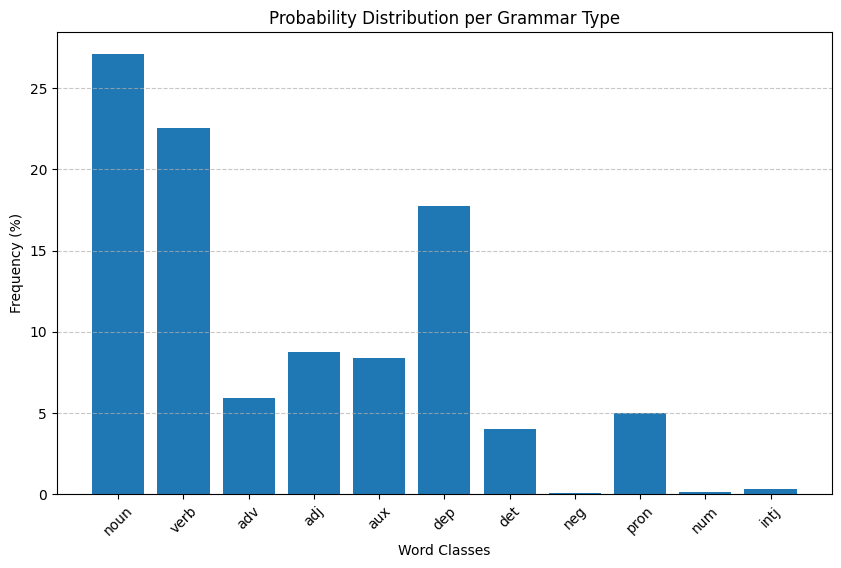

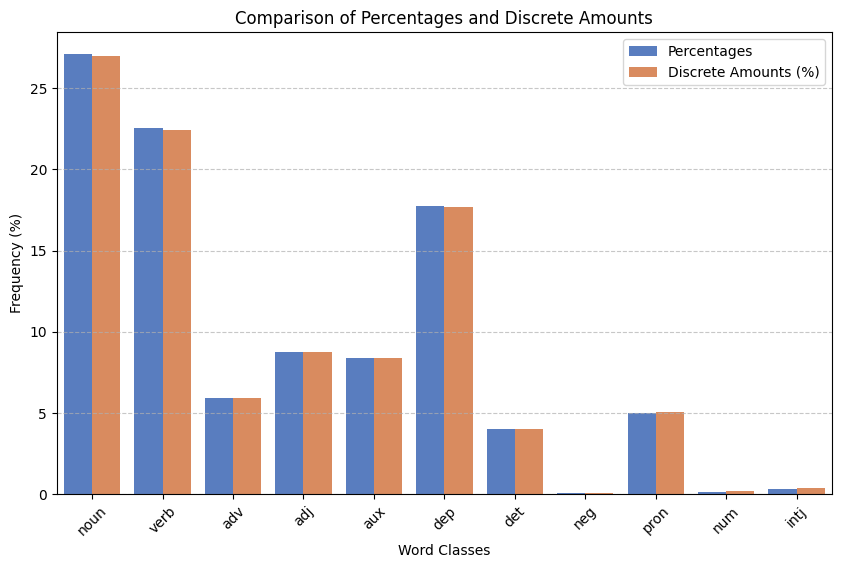

In [63]:
korean_final, class_prior_fig, hamilton_fig = create_sorted_flashcard_set(
    data=korean_raw,
    data_columns=["단어", "품사", "frequency_est"],
    pos_str="pos",
    frequency_str="frequency",
    rank_by="frequency",
    lang="korean",
    target_columns=["word", "pos", "frequency"],
    drop_pos=[],
    limit=TOTAL_SIZE,
)

display(korean_final)
display(class_prior_fig[0])
display(hamilton_fig[0])

### Technical Setup

Technical implementation involves prompting, model design, flashcard imports, batch managements and running to gather data about the performance of measurable components of the system.

In this case testing to ask about different components of the swedish language and see how it performs.

In [4]:
from vllm.transformers_utils.tokenizer import get_tokenizer
from openai import OpenAI

from src.ai.models import Custom_vLLM, Vanilla_vLLM, Vanilla_ChatGPT
from src.ai.prompts import GENERATOR_SYSTEM_PROMPT
from src.ai.vLLM import vLLM_run, initialize_vLLM

In [5]:
# load word lists
english_vocab = pd.read_csv(f"data/3-final/english{TOTAL_SIZE}.csv").sort_values(
    by="frequency", ascending=False
)
swedish_vocab = pd.read_csv(f"data/3-final/swedish{TOTAL_SIZE}.csv").sort_values(
    by="frequency", ascending=False
)
spanish_vocab = pd.read_csv(f"data/3-final/spanish{TOTAL_SIZE}.csv").sort_values(
    by="frequency", ascending=False
)
korean_vocab = pd.read_csv(f"data/3-final/korean{TOTAL_SIZE}.csv").sort_values(
    by="frequency", ascending=False
)

# Lists of allowed words
english_word_list = english_vocab["word"].tolist()
swedish_word_list = swedish_vocab["word"].tolist()
spanish_word_list = spanish_vocab["word"].tolist()
korean_word_list = korean_vocab["word"].tolist()

# Lemmatizers
english_lemmatizer = spacy.load("en_core_web_sm")  # for English (small)
# english_lemmatizer = spacy.load("en_core_web_trf")  # for English (large)
swedish_lemmatizer = spacy.load("sv_core_news_sm")  # for Swedish (small)
# swedish_lemmatizer = spacy.load("sv_core_news_lg")  # for Swedish (large)
spanish_lemmatizer = spacy.load("es_core_news_sm")  # for Spanish (small)
# spanish_lemmatizer = spacy.load("es_dep_news_trf")  # for Spanish (large)
korean_lemmatizer = spacy.load("ko_core_news_sm")  # for Korean (small)
# korean_lemmatizer = spacy.load("ko_core_news_lg")  # for Korean (large)

In [6]:
test_questions_english = [
    
] # TODO

test_questions_swedish = [  # Make some test questions
    "What's the difference between 'en' and 'ett' in swedish?",
    "When do you use 'är' vs 'har' in swedish?",
    "Why do you say 'jag heter' instead of 'jag är' in swedish?",
    "What does 'lagom' mean in swedish?",
    "How do I know if a word is a 'ett' or 'en' word in swedish?",
]

test_questions_spanish = [
    "What is the difference between 'el' and 'la' in spanish?"
    "What is the difference between 'está' and 'estaba' in spanish?"
    "" # TODO
]

test_questions_korean = [

] # TODO

In [ ]:
# HYPERPARAMETERS
# --------------------------------------------/>

# Models vLLM
VLLM_MODEL_NAME = "Qwen/Qwen2.5-3B-Instruct-AWQ"# Light model with AWQ quantization
# MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct-AWQ"   # Heavier model with AWQ quantization

# Models ChatGPT
# OPENAI_MODEL_NAME = "gpt-4o-mini"               # Lighter OpenAI model
OPENAI_MODEL_NAME = "gpt-5.2"                   # Heavier OpenAI model

# vLLM Initialization
DTYPE = "half"                                  # dtype
GPU_MEMORY_UTILIZATION = 0.6                    # GPU Memory Utilization
MAX_MODEL_LEN = 30000                           # Maximum allowed tokens to be generated by the vLLM model. 
ENABLE_PREFIX_CACHING = True                    # IMPORTANT: "caches the KV cache of existing queries, so that a new query can directly reuse the KV cache if it shares the same prefix with one of the existing queries, allowing the new query to skip the computation of the shared part." -- vLLM Documentation (https://docs.vllm.ai/en/latest/features/automatic_prefix_caching/)

# Sampling Parameters
TEMPERATURE = 0.5                               # Temperature
# TOP_K = 0.9                                   # Top K
MAX_TOKENS = 1                                  # Max generated tokens at a time. Keep at 1 for beam search logic
BEAM_SIZE = 2                                   # Beam Size
BEAM_CONSTRAINT_PADDING = 20                    # Extra padding to have backup logprobs in case too many gets pruned from vocabulary or probability constraints. Lower decreases sampling detail in constrained beam search
LOGPROBS = BEAM_SIZE + BEAM_CONSTRAINT_PADDING  # Number of logprobs to extract from vLLM
REPETITION_PENALTY = 2                          # vLLM repetition penalty, default 1 (https://docs.vllm.ai/en/v0.6.5/dev/sampling_params.html)
PRESENCE_PENALTY = 0.0                          # vLLM presence penalty, default 0 (https://docs.vllm.ai/en/v0.6.5/dev/sampling_params.html)
FREQUENCY_PENALTY = 0.2                         # vLLM frequency penalty, default 0 (https://docs.vllm.ai/en/v0.6.5/dev/sampling_params.html)
LOGITS_PREPROCESSORS = []                       # vLLM Logits Preprocessors
LOGPROB_NORM_ALPHA = 0.2                        # Weight variable for Normalized Logprobs, 1 = fully equal, makes longer sequences always better, 0 = no effect, default = 0.6

# Sequence Generation
MAX_RESPONSE_TOKEN_LENGTH = 300                 # Nr allowed token length for the final sequence length
USE_WORD_CONSTRAINT = True                      # Applies penalty term on words' logprob which are not in allowed vocabulary
WORD_CONSTRAINT_TYPE = "soft"                   # "soft" | "hard", applies 
WORD_SOFT_CONSTRAINT_PENALTY = 1                # Soft penalty to discourage use of non-allowed words while allowing some slack. Increase if using too many non-allowed words

# Misc
VERBOSE = "sequence"                            # "full" | "sequence" | None Prints progress from inference

# --------------------------------------------/>

# Improvement Loop
MIN_ROUNDS = 1                                  # Minimum amount of rounds to run improvement loop
MAX_ROUNDS = 3                                  # Maximum amount of rounds to run improvement loop
CONVERGENCE_SCORE=4.3                           # Minimum score to allow loop convergence
CONVERGENCE_VARIANCE=0.3                        # Maximum allowed variance to allow loop convergence

# --------------------------------------------/>

In [8]:
# Initialize models

# vLLM
llm = initialize_vLLM(
    model=VLLM_MODEL_NAME,
    dtype=DTYPE,
    gpu_memory_utilization=GPU_MEMORY_UTILIZATION,
    max_model_len=MAX_MODEL_LEN,
    enable_prefix_caching=ENABLE_PREFIX_CACHING,  # IMPORTANT: Enables KV Cahce reuse between queries with shared prefixes
    max_logprobs=LOGPROBS + 20,  # overhead to switch up and down
    trust_remote_code=True,
)

tokenizer = get_tokenizer(VLLM_MODEL_NAME)

# OpenAI
client = OpenAI(api_key=os.getenv("OPENAI_KEY"))

[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0


Loading safetensors checkpoint shards:   0% Completed | 0/1 [00:00<?, ?it/s]
Loading safetensors checkpoint shards: 100% Completed | 1/1 [00:00<00:00,  2.49it/s]
Loading safetensors checkpoint shards: 100% Completed | 1/1 [00:00<00:00,  2.48it/s]
(EngineCore pid=1318548) 
Capturing CUDA graphs (mixed prefill-decode, PIECEWISE): 100%|██████████| 51/51 [00:03<00:00, 15.43it/s]
Capturing CUDA graphs (decode, FULL): 100%|██████████| 35/35 [00:01<00:00, 20.90it/s]


In [9]:
# Sampling Parameters for vLLM models
custom_sampling_params = SamplingParams(
    temperature=TEMPERATURE,
    max_tokens=MAX_TOKENS,
    logprobs=LOGPROBS,
    repetition_penalty=REPETITION_PENALTY,
    # presence_penalty=PRESENCE_PENALTY,
    frequency_penalty=FREQUENCY_PENALTY,
)

vanilla_sampling_params = SamplingParams(
    temperature=TEMPERATURE,
    max_tokens=MAX_RESPONSE_TOKEN_LENGTH,
    logprobs=0, # 0 means only get logprob of sampled word. Needed for perplexity calculation
    repetition_penalty=REPETITION_PENALTY,
    # presence_penalty=PRESENCE_PENALTY,
    frequency_penalty=FREQUENCY_PENALTY,
)

In [10]:
# Per-Language model initialization

# Custom vLLM Model
custom_vllm_english = Custom_vLLM(
    model=llm,
    tokenizer=tokenizer,
    lemmatizer=english_lemmatizer,
    allowed_words=english_word_list,
    beam_size=BEAM_SIZE,
    word_soft_constraint_penalty=WORD_SOFT_CONSTRAINT_PENALTY,
    alpha=LOGPROB_NORM_ALPHA
)
custom_vllm_swedish = Custom_vLLM(
    model=llm,
    tokenizer=tokenizer,
    lemmatizer=swedish_lemmatizer,
    allowed_words=swedish_word_list,
    beam_size=BEAM_SIZE,
    word_soft_constraint_penalty=WORD_SOFT_CONSTRAINT_PENALTY,
    alpha=LOGPROB_NORM_ALPHA
)
custom_vllm_spanish = Custom_vLLM(
    model=llm,
    tokenizer=tokenizer,
    lemmatizer=spanish_lemmatizer,
    allowed_words=spanish_word_list,
    beam_size=BEAM_SIZE,
    word_soft_constraint_penalty=WORD_SOFT_CONSTRAINT_PENALTY,
    alpha=LOGPROB_NORM_ALPHA
)
custom_vllm_korean = Custom_vLLM(
    model=llm,
    tokenizer=tokenizer,
    lemmatizer=korean_lemmatizer,
    allowed_words=korean_word_list,
    beam_size=BEAM_SIZE,
    word_soft_constraint_penalty=WORD_SOFT_CONSTRAINT_PENALTY,
    alpha=LOGPROB_NORM_ALPHA
)

# Vanilla vLLM Model
vanilla_vllm_english = Vanilla_vLLM(model=llm, tokenizer=tokenizer, allowed_words=english_word_list)
vanilla_vllm_swedish = Vanilla_vLLM(model=llm, tokenizer=tokenizer, allowed_words=swedish_word_list)
vanilla_vllm_spanish = Vanilla_vLLM(model=llm, tokenizer=tokenizer, allowed_words=spanish_word_list)
vanilla_vllm_korean = Vanilla_vLLM(model=llm, tokenizer=tokenizer, allowed_words=korean_word_list)

# ChatGPT 5.2
vanilla_chatgpt_english = Vanilla_ChatGPT(client=client, model=OPENAI_MODEL_NAME, allowed_words=english_word_list)
vanilla_chatgpt_swedish = Vanilla_ChatGPT(client=client, model=OPENAI_MODEL_NAME, allowed_words=swedish_word_list)
vanilla_chatgpt_spanish = Vanilla_ChatGPT(client=client, model=OPENAI_MODEL_NAME, allowed_words=spanish_word_list)
vanilla_chatgpt_korean = Vanilla_ChatGPT(client=client, model=OPENAI_MODEL_NAME, allowed_words=korean_word_list)

### Improvement Loop

Improvement loop loops between model and corrector to improve the final output to later measure the improvement and total performance in real-world tasks of this subsystem.

In [11]:
nr_languages = len(get_args(LANGUAGES))
nr_questions_english = len(test_questions_english)
nr_questions_swedish = len(test_questions_swedish)
nr_questions_spanish = len(test_questions_spanish)
nr_questions_korean = len(test_questions_korean)
nr_questions_total = nr_questions_english + nr_questions_swedish + nr_questions_spanish + nr_questions_korean
nr_samples = MODEL_SAMPLE_SIZE
nr_batches = (TOTAL_SIZE // BATCH_SIZE) if isinstance(BATCH_SIZE, int) else len(BATCH_SIZE)

nr_runs_min = MIN_ROUNDS
nr_runs_max = MAX_ROUNDS

nr_runs_min = nr_questions_total * nr_batches * nr_samples * nr_runs_min
nr_runs_max = nr_questions_total * nr_batches * nr_samples * nr_runs_max

per_run_time_est = 30 # in seconds
total_time_min_hrs = (((nr_runs_min * per_run_time_est)/60)/60)
total_time_min_days = (((nr_runs_min * per_run_time_est)/60)/60)/24
total_time_max_hrs = (((nr_runs_max * per_run_time_est)/60)/60)
total_time_max_days = (((nr_runs_max * per_run_time_est)/60)/60)/24

total_time_min = f"{total_time_min_days} days" if total_time_min_hrs >= 24 else f"{total_time_min_hrs} hours"
total_time_max = f"{total_time_max_days} days" if total_time_max_hrs >= 24 else f"{total_time_max_hrs} hours"


print(
    f"""
Current Setup:
    Total Nr. Languages:                     | {nr_languages}
                                             |
    Total Nr. Questions English:             | {nr_questions_english}
    Total Nr. Questions Swedish:             | {nr_questions_swedish}
    Total Nr. Questions Spanish:             | {nr_questions_spanish}
    Total Nr. Questions Korean:              | {nr_questions_korean}
                                             |
    Total Nr. Language Questions:            | {nr_questions_total}
                                             |
    Flashcard Set Size:                      | {TOTAL_SIZE}
    Batch Size:                              | {BATCH_SIZE}
    Total Nr. Batches:                       | {nr_batches}
                                             |
    Total Nr. Samples (of generator model):  | {MODEL_SAMPLE_SIZE}
                                             |
    Total Nr. Runs:                          | Min: {nr_runs_min}, Max: {nr_runs_max}
    Total Est. Time                          | Min: {total_time_min}, Min: {total_time_max}, (Avg. {per_run_time_est} sec./gen)
"""
)


Current Setup:
    Total Nr. Languages:                     | 4
                                             |
    Total Nr. Questions English:             | 0
    Total Nr. Questions Swedish:             | 5
    Total Nr. Questions Spanish:             | 1
    Total Nr. Questions Korean:              | 0
                                             |
    Total Nr. Language Questions:            | 6
                                             |
    Flashcard Set Size:                      | 2000
    Batch Size:                              | [100, 500, 2000]
    Total Nr. Batches:                       | 3
                                             |
    Total Nr. Samples (of generator model):  | 100
                                             |
    Total Nr. Runs:                          | Min: 1800, Max: 5400
    Total Est. Time                          | Min: 15.0 hours, Min: 1.875 days, (Avg. 30 sec./gen)



In [12]:
from src.corrector.multiagentic_judge.run import (
    EvaluationConfig,
    ModelConfig,
    Profile,
    IssueLedger,
    RoundResult,
    evaluate_round,
    check_convergence,
    IterativeEvaluationResult,
    build_generator_context,
)
from src.corrector.multiagentic_judge.configs import DEFAULT_RUBRIC, CORRECTOR_RUBRIC
from src.ai.prompts import GENERATOR_SYSTEM_PROMPT

Generators = Union[Custom_vLLM, Vanilla_vLLM, Vanilla_ChatGPT]
Verbosity = Literal["full", "sequence", None]

In [13]:
# Evaluation config for the LLM-as-a-judge system
config = EvaluationConfig(
    model_config=ModelConfig(
        profiles={
            "factuality": Profile(
                family="openai",
                model="gpt-4o-mini",
                temperature=0.3,
            ),
            "linguistics": Profile(
                family="openai",
                model="gpt-4o-mini",
                temperature=0.3,
            ),
            "depth": Profile(
                family="openai",
                model="gpt-4o-mini",
                temperature=0.3,
            ),
            "reasoning": Profile(
                family="openai",
                model="gpt-4o-mini",
                temperature=0.3,
            ),
            "synthesis": Profile(
                family="openai",
                model="gpt-4o-mini",
                temperature=0.3,
            ),
        },
    ),
    rubric=CORRECTOR_RUBRIC,
    min_rounds=MIN_ROUNDS,
    max_rounds=MAX_ROUNDS,
    convergence_score=CONVERGENCE_SCORE,
    convergence_variance=CONVERGENCE_VARIANCE,
)

In [14]:
async def run_self_iteration(
    system_prompt: str,
    prompt: str,
    generator: Generators,
    config: EvaluationConfig,
    sampling_params: SamplingParams,
    language: str,
    sample_nr: int,
    prompt_allowed_words: bool = False,
    verbose: Verbosity = "sequence",
):

    ledger = IssueLedger()
    rounds: list[RoundResult] = []
    converged = False
    convergence_reason = None

    save_path = f"chats/self-iteration/{language}/sample{sample_nr}"
    os.makedirs(save_path, exist_ok=True)

    output, perplexity = generator(
        system_prompt,
        prompt,
        sampling_params,
        MAX_RESPONSE_TOKEN_LENGTH,
        prompt_allowed_words=prompt_allowed_words,
        verbose=verbose,
    )

    # starting improvement loop
    for round_num in range(1, config.max_rounds + 1):
        feedback = ledger.to_prompt_block() if round_num > 1 else None

        review, updated_ledger = await evaluate_round(
            llm_output=output,
            context=prompt,
            ledger=ledger,
            round_number=round_num,
            config=config,
        )

        ledger = updated_ledger  # update with news

        round_result = RoundResult(
            round_number=round_num,
            generated_text=output,
            perplexity=perplexity,
            review=review,
            ledger_snapshot=ledger.model_copy(deep=True),
        )
        rounds.append(round_result)
        print(f"Round {round_num} completed. Saving...") if verbose is True else None

        # save round
        with open(f"{save_path}/iter{round_num}.json", "w", encoding="utf-8") as f:
            f.write(round_result.model_dump_json(indent=4))

        # save generated tree if generator has one
        has_beam_tree = getattr(generator, "beam_tree", None)
        if has_beam_tree:
            generator.beam_tree.visualize_tree(f"{round_num}_tree", path=f"{save_path}")

        print(f"Round {round_num} Saved.") if verbose is True else None

        converged, convergence_reason = check_convergence(review, config, round_num)

        if converged:
            break

        # generate
        ctx = build_generator_context(round_num, prompt, rounds, ledger)

        prompt = ctx.to_prompt()

        output, perplexity = generator(
            system_prompt,
            prompt,
            sampling_params,
            MAX_RESPONSE_TOKEN_LENGTH,
            prompt_allowed_words=prompt_allowed_words,
            verbose=verbose,
        )

    best_round = max(rounds, key=lambda r: r.review.overall_score)

    final_result = IterativeEvaluationResult(
        rounds=rounds,
        final_output=best_round.generated_text,
        final_score=best_round.review.overall_score,
        converged=converged,
        convergence_reason=convergence_reason,
    )

    return final_result

In [15]:
final_result = await run_self_iteration(
    "You are a helpful assistant in swedish",
    "What is the difference between 'en' and 'ett' in swedish?",
    custom_vllm_english,
    config,
    vanilla_sampling_params,
    "english",
    1,
    False,
    "sequence",
)

print("\n=== RESULTS ===")
for r in final_result.rounds:
    print(
        f"Round {r.round_number}: {r.review.overall_score}/5.0 ({r.review.letter_grade}) | "
        f"Variance: {r.review.score_variance} | Confidence: {r.review.confidence}"
    )
    print(
        f"  Open issues: {sum(1 for i in r.ledger_snapshot.issues if i.status == 'open')}"
    )

print(f"\nConverged: {final_result.converged}")
if final_result.convergence_reason:
    print(f"Reason: {final_result.convergence_reason}")
print(f"Final score: {final_result.final_score}/5.0")
print(f"\nBest output:\n{final_result.final_output}")

Sequence step: 1
Sequence step: 2
Sequence step: 3
Sequence step: 4
Sequence step: 5
Sequence step: 6
Sequence step: 7
Sequence step: 8
Sequence step: 9
Sequence step: 10
Sequence step: 11
Sequence step: 12
Sequence step: 13
Sequence step: 14
Sequence step: 15
Sequence step: 16
Sequence step: 17
Sequence step: 18
Sequence step: 19
Sequence step: 20
Sequence step: 21
Sequence step: 22
Sequence step: 23
Sequence step: 24
Sequence step: 25
Sequence step: 26
Sequence step: 27
Sequence step: 28
Sequence step: 29
Sequence step: 30
Sequence step: 31
Sequence step: 32
Sequence step: 33
Sequence step: 34
Sequence step: 35
Sequence step: 36
Sequence step: 37
Sequence step: 38
Sequence step: 39
Sequence step: 40
Sequence step: 41
Sequence step: 42
Sequence step: 43
Sequence step: 44
Sequence step: 45
Sequence step: 46
Sequence step: 47
Sequence step: 48
Sequence step: 49
Sequence step: 50
Sequence step: 51
Sequence step: 52
Sequence step: 53
Sequence step: 54
Sequence step: 55
Sequence step: 56
S

IndexError: list index out of range

### Evaluation

In [ ]:
# Placeholder function to calculate % used of allowed words
def calculate_lexical_percentage(chosen_final_answer, chosen_vocab):
    final_answer_list = re.sub(r"[^\w\s]", "", contractions.fix(chosen_final_answer))

    doc = nlp(final_answer_list)
    lemmas = [item.lemma_ for item in doc]
    pos = [item.pos_ for item in doc]

    excluded_classes = set(["X", "SYM", "PROPN", "NUM", "SPACE", "PUNCT"])

    exclude_indecies = [i for i, item in enumerate(pos) if item in excluded_classes]

    final_answer_list = [
        item for i, item in enumerate(lemmas) if i not in exclude_indecies
    ]
    pos = [item for i, item in enumerate(pos) if i not in exclude_indecies]

    counter = sum(1 for x in final_answer_list if x in chosen_vocab)
    total = len(final_answer_list)

    for x in final_answer_list:
        if x not in chosen_vocab:
            print(x)

    return f"{round((counter/total) * 100, 2)}%"

### Statistics Modeling

In statistics modeling it includes importing the created outputs and running the corrector to both get useful data for later evaluation, and prompting for iterative improvements

In [ ]:
from ai.OLD_models import Corrector
from ai.OLD_prompts import LLM_LEXICAL_SYSTEM_PROMPT

In [ ]:
corrector = Corrector() # Define corrector

# make flashcards into a list
list_of_flashcards = conversation.flashcards.split("\n")

# fake_history = [
#     {
#         "role": "user",
#         "content": [{"type": "output_text", "text": "Jag älskar pommes. Det måste finnas i mitt liv."}],
#     },
# ]

# corrector.fit(fake_history, list_of_flashcards)
corrector.fit(conversations_data, list_of_flashcards)

In [ ]:
display(Markdown(conversations_data[1].response))

In [ ]:
# Testing lexical constraints one time

## Lexical classification using separate LLM
llm_classified = corrector.lexical.llm_classification(client, "gpt-4o-mini", LLM_LEXICAL_SYSTEM_PROMPT)
# display(llm_classified.head(5)) # structure


llm_classification_ci_news = [[] for _ in range(MODEL_SAMPLE_SIZE)]
llm_classification_ci_olds = [[] for _ in range(MODEL_SAMPLE_SIZE)]

for obj in conversations_data:

    ci_old_ratio = 100 - round(obj.lexical.llm_classification["is_new"].to_numpy().sum()/len(obj.lexical.llm_classification["is_new"].tolist()) * 100)
    ci_new_ratio = round(
        obj.lexical.llm_classification["is_new"].to_numpy().sum()
        / len(obj.lexical.llm_classification["is_new"].tolist())
        * 100
    )

    print(f"Model CI ratio according to LLM (old/new): {ci_old_ratio}/{ci_new_ratio}")

    llm_classification_ci_news[obj.sample_id].append(ci_new_ratio)
    llm_classification_ci_olds[obj.sample_id].append(ci_old_ratio)


## Lexical classification using traditional NLP

In [ ]:
# test_corrector = Corrector()
# test_corrector.fit([
#     {
#         "role": "user",
#         "content": [{"type": "output_text", "text": "Jag älskar pommes. Det måste finnas i mitt liv."}],
#     },
# ], list_of_flashcards)


res = corrector.lexical.raw_checking()

raw_checking_ci_news = [[] for _ in range(MODEL_SAMPLE_SIZE)]
raw_checking_ci_olds = [[] for _ in range(MODEL_SAMPLE_SIZE)]

for obj in conversations_data:

    ci_old_ratio = 100 - round(obj.lexical.raw_checking["score"].to_numpy().sum()/len(obj.lexical.raw_checking["score"].tolist()) * 100)
    ci_new_ratio = round(
        obj.lexical.raw_checking["score"].to_numpy().sum()
        / len(obj.lexical.raw_checking["score"].tolist())
        * 100
    )

    print(f"Model CI ratio according to traditional NLP (old/new): {ci_old_ratio}/{ci_new_ratio}")

    raw_checking_ci_news[obj.sample_id].append(ci_new_ratio)
    raw_checking_ci_olds[obj.sample_id].append(ci_old_ratio)

In [ ]:
# Process CI ratios to put all samples together for calculating std etc
x = np.linspace(BATCH_SIZE, TOTAL_SIZE, TOTAL_SIZE // BATCH_SIZE)

y_llm_classification = np.array(llm_classification_ci_news)
llm_classification_means = np.mean(y_llm_classification, axis=0)
llm_classification_stds = np.std(y_llm_classification, axis=0)


y_raw_checking = np.array(raw_checking_ci_news)
raw_checking_means = np.mean(y_raw_checking, axis=0)
raw_checking_stds = np.std(y_raw_checking, axis=0)

In [ ]:
# Lineplot using

fig, axis = plt.subplots(1, 2, figsize=(20, 6))

axis[0].plot(
    x,
    llm_classification_means,
    label="(Mean) Words classified as NOT being from the Allowed Flashcards List",
    color="red",
)
axis[0].fill_between(
    x,
    llm_classification_means - llm_classification_stds,
    llm_classification_means + llm_classification_stds, alpha=0.3, label="Standard Deviation", color="orange")
axis[0].set_title(f"% of total tokens in output text classified BY AN LLM as being outside Allowed Flashcard List")

axis[1].plot(
    x,
    raw_checking_means,
    label="(Mean) Words classified as NOT being from the Allowed Flashcards List",
    color="red",
)
axis[1].fill_between(
    x,
    raw_checking_means - raw_checking_stds,
    raw_checking_means + raw_checking_stds,
    alpha=0.3,
    label="Standard Deviation",
    color="orange"
)
axis[1].set_title(
    f"% of total tokens in output text classified BY TRADITIONAL NLP as being outside Allowed Flashcard List"
)

for ax in axis:
    ax.grid(axis="y", linestyle="--", alpha=0.7)
    ax.set_ylim(0, 100)
    ax.axhline(y=10, linestyle="--", label="Maximum Allowed Threshold")
    ax.set_xlabel("Nr. Unique Allowed Flashcards")
    ax.set_ylabel("Classification (%)")
    ax.legend()

plt.show()